# Saga 4 — Comportamiento Temporal del Sistema
**Pregunta rectora:** ¿Por qué el sector oscila entre escasez y sobreinversión?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mise_utils import colombia_sin, dynamics, viz, saga
viz.apply_mise_style()

state = saga.load_state('saga')

  Estado cargado: C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl (7 capas: ['identidad', 'red_fisica', 'red_social', 'dinamica', 'politica', 'gobernanza', 'datos_reales'])


### 4.1 Datos históricos del SIN (2000-2024)

,year,precio_avg,precio_max,precio_min,generacion_GWh,demanda_max_MW,demanda_GWh,margen_reserva_pct
0,2000,44.741239,96.13793,21.53117,41278.096033,7617.0,NaN,NaN
1,2001,52.700019,118.07276,24.82288,43047.722825,7783.0,NaN,NaN
2,2002,48.766786,138.54749,26.77768,44735.127479,8018.0,NaN,NaN
3,2003,66.778759,148.00360,37.01344,46734.196114,8050.0,NaN,NaN
4,2004,64.184329,189.90277,32.25300,48561.827947,8332.0,NaN,NaN


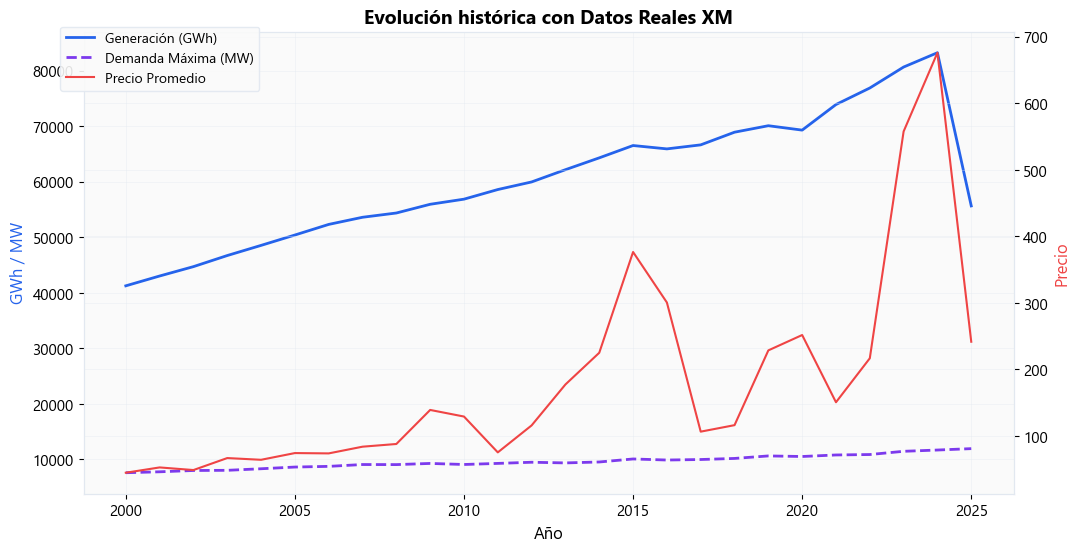

In [2]:
from mise_utils import data_loader
hist = data_loader.serie_anual_integrada()
display(hist.head())

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(hist['year'], hist['generacion_GWh'], color=viz.COLORS.get('primary', 'blue'), linewidth=2, label='Generación (GWh)')
ax1.plot(hist['year'], hist['demanda_max_MW'], color=viz.COLORS.get('secondary', 'green'), linewidth=2, linestyle='--', label='Demanda Máxima (MW)')
ax1.set_xlabel('Año')
ax1.set_ylabel('GWh / MW', color=viz.COLORS.get('primary', 'blue'))

ax2 = ax1.twinx()
ax2.plot(hist['year'], hist['precio_avg'], color=viz.COLORS.get('danger', 'red'), linewidth=1.5, label='Precio Promedio')
ax2.set_ylabel('Precio', color=viz.COLORS.get('danger', 'red'))

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Evolución histórica con Datos Reales XM', fontweight='bold')
plt.show()

**Hallazgo Clave:** Los datos reales (Saga 0) confirman: curtosis=22, ciclos de 7-12 años, relación exponencial embalse-precio.

### 4.2 Modelo básico de inversión-capacidad

El modelo representa la dinámica mediante tres variables de estado (stocks): Capacidad, Pipeline (proyectos en construcción) y Demanda. Existen dos bucles de retroalimentación principales:
- **Refuerzo:** Precio alto $\rightarrow$ mayor inversión.
- **Balance:** Nueva capacidad (tras el retardo) $\rightarrow$ precio baja.

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Capacidad vs Demanda'}, ylabel='MW'>,
         <Axes: title={'center': 'Precio de Bolsa'}, ylabel='COP/kWh'>],
        [<Axes: title={'center': 'Pipeline de Proyectos'}, xlabel='Año', ylabel='MW en construcción'>,
         <Axes: title={'center': 'Margen de Reserva'}, xlabel='Año', ylabel='Margen de reserva (%)'>]],
       dtype=object))

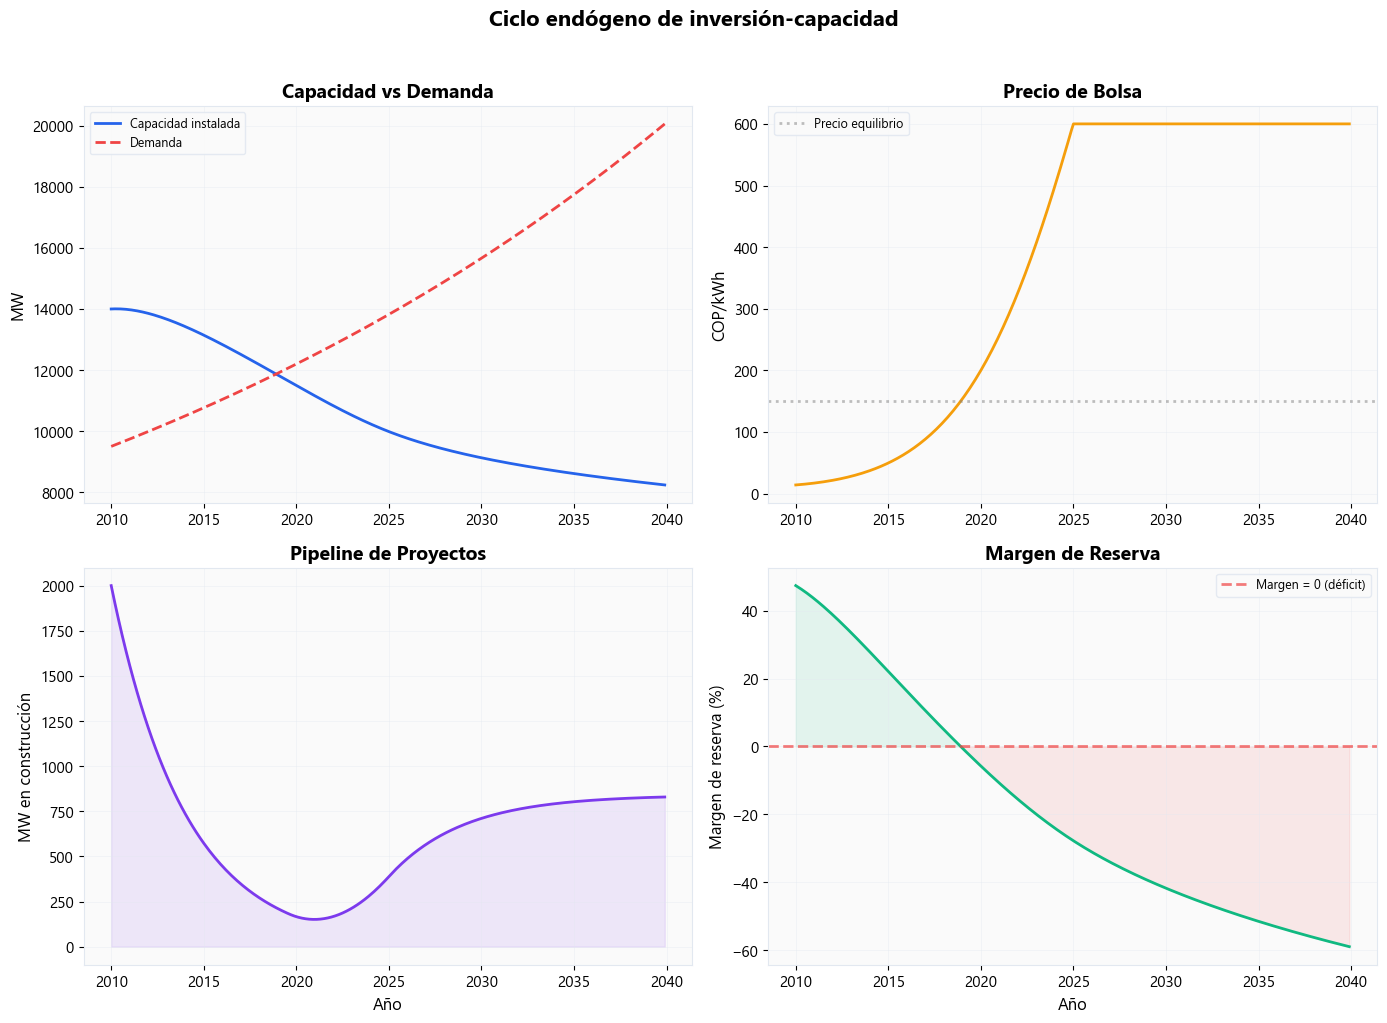

In [3]:
df_base = dynamics.modelo_inversion_capacidad()
dynamics.plot_ciclo_inversion(df_base, titulo='Ciclo endógeno de inversión-capacidad')

**El modelo reproduce oscilaciones endógenas sin ningún shock externo — las oscilaciones son una propiedad emergente de la estructura de retroalimentación con retardo, no un accidente**

🔍 **Dos miradas**
* **Convencional:** La capacidad crece linealmente con la inversión. Proyectemos con tendencia.
* **Complejo:** Las oscilaciones son ENDÓGENAS — emergen del retardo de construcción + retroalimentación no-lineal precio-inversión. No necesitas El Niño para tener crisis: la crisis es una propiedad emergente del sistema.
* **Diferencia:** UPME proyecta linealmente. El modelo SD predice oscilaciones que ninguna regresión lineal captura.

### 4.3 Sensibilidad al retardo de construcción

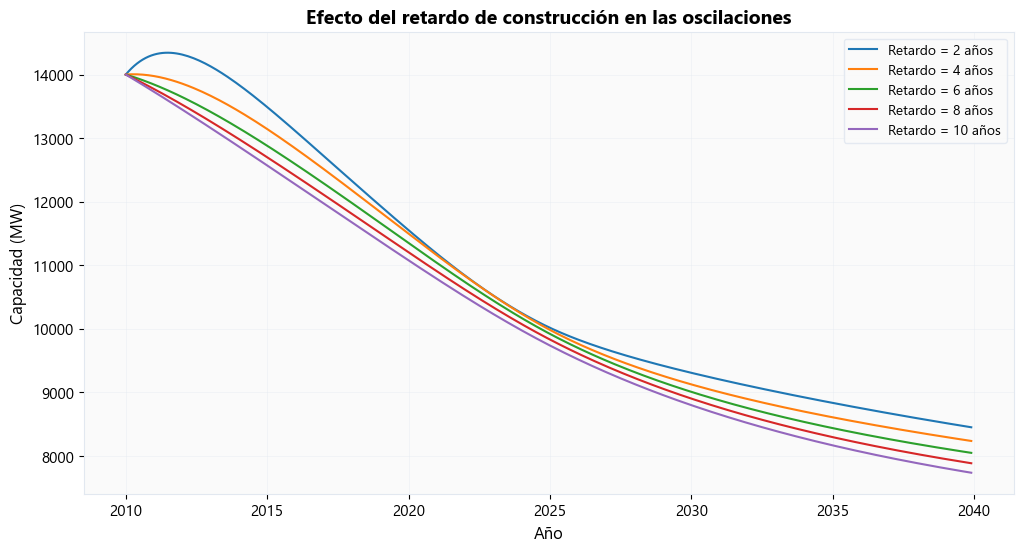

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
for delay in [2, 4, 6, 8, 10]:
    df = dynamics.modelo_inversion_capacidad(params={'delay_construccion': delay})
    ax.plot(df['año'], df['capacidad_MW'], linewidth=1.5, label=f'Retardo = {delay} años')
ax.set_xlabel('Año'); ax.set_ylabel('Capacidad (MW)')
ax.set_title('Efecto del retardo de construcción en las oscilaciones', fontweight='bold')
ax.legend()
plt.show()

**Mayor retardo = oscilaciones más amplias y lentas. Con retardo de 8 años, la amplitud del ciclo se duplica — esto explica por qué proyectos de larga maduración (hidroeléctricas, transmisión) generan ciclos más severos que renovables de rápida instalación**

### 4.4 Modelo extendido con CxC y FNCER

El modelo extendido incluye 5 variables de estado (stocks): `capacidad_termica`, `capacidad_renovable`, `pipeline_termica`, `pipeline_renovable`, y `demanda`. Permite evaluar cómo la penetración de renovables (FNCER) y el mecanismo de Cargo por Confiabilidad (CxC) alteran la dinámica de largo plazo.

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Capacidad vs Demanda'}, ylabel='MW'>,
         <Axes: title={'center': 'Precio de Bolsa'}, ylabel='COP/kWh'>],
        [<Axes: title={'center': 'Pipeline de Proyectos'}, xlabel='Año', ylabel='MW en construcción'>,
         <Axes: title={'center': 'Participación Renovable en la Matriz'}, xlabel='Año', ylabel='Participación renovable (%)'>]],
       dtype=object))

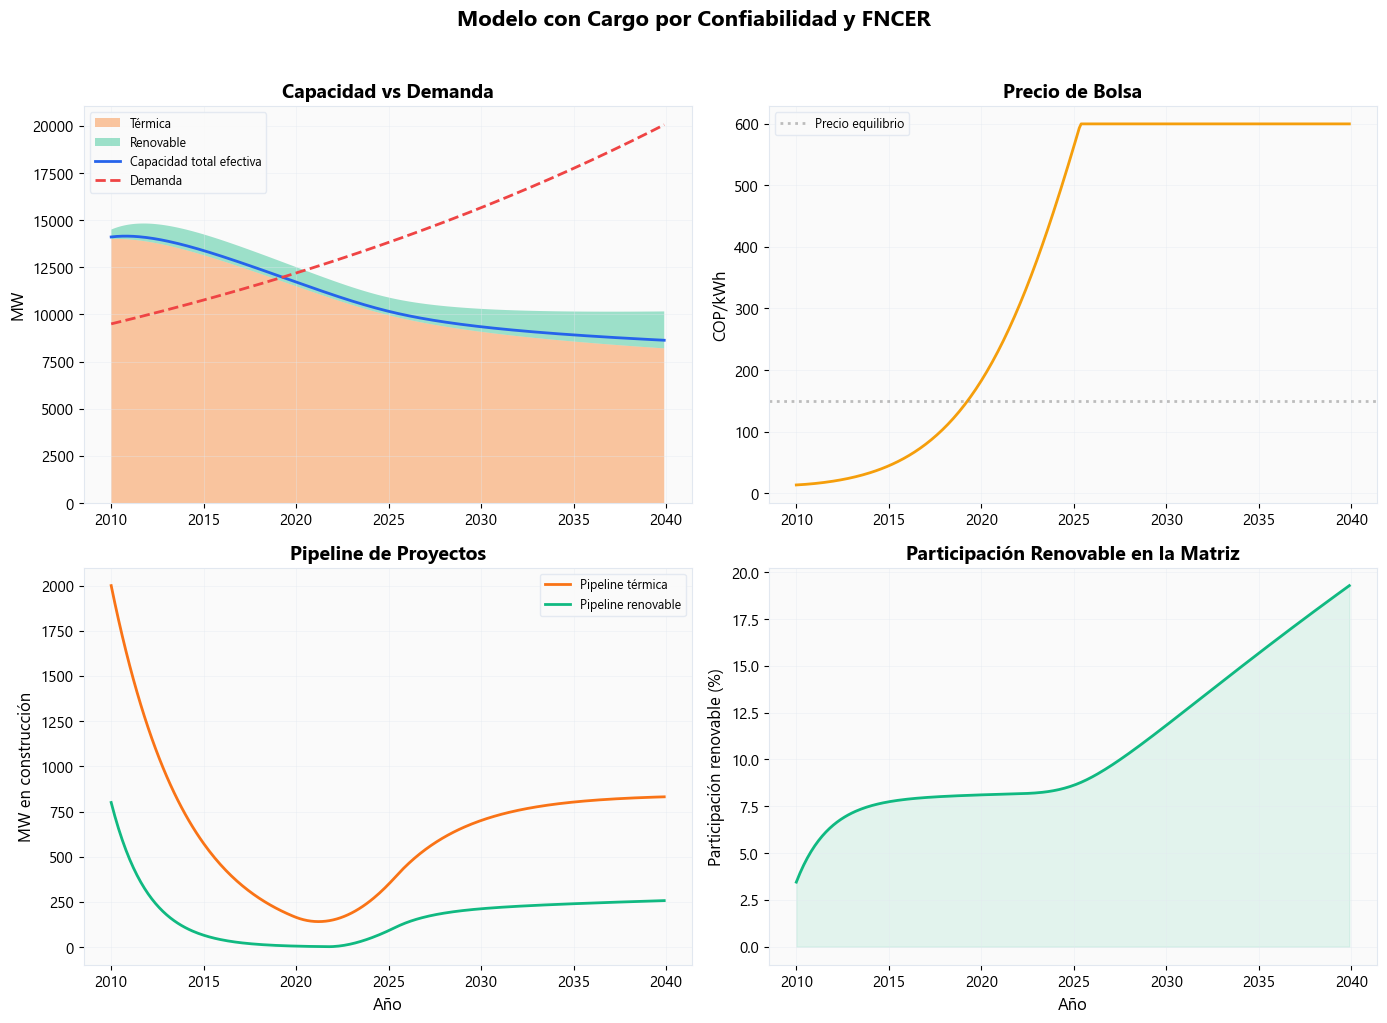

In [5]:
df_cxc = dynamics.modelo_inversion_con_cxc_fncer()
dynamics.plot_ciclo_inversion(df_cxc, titulo='Modelo con Cargo por Confiabilidad y FNCER')

**La inclusión de renovables con CxC cambia la dinámica: la capacidad térmica se estabiliza pero crea una nueva tensión — la velocidad de entrada de renovables vs la inercia de retiro de termoeléctricas**

### 4.5 Comparación CxC activo vs inactivo

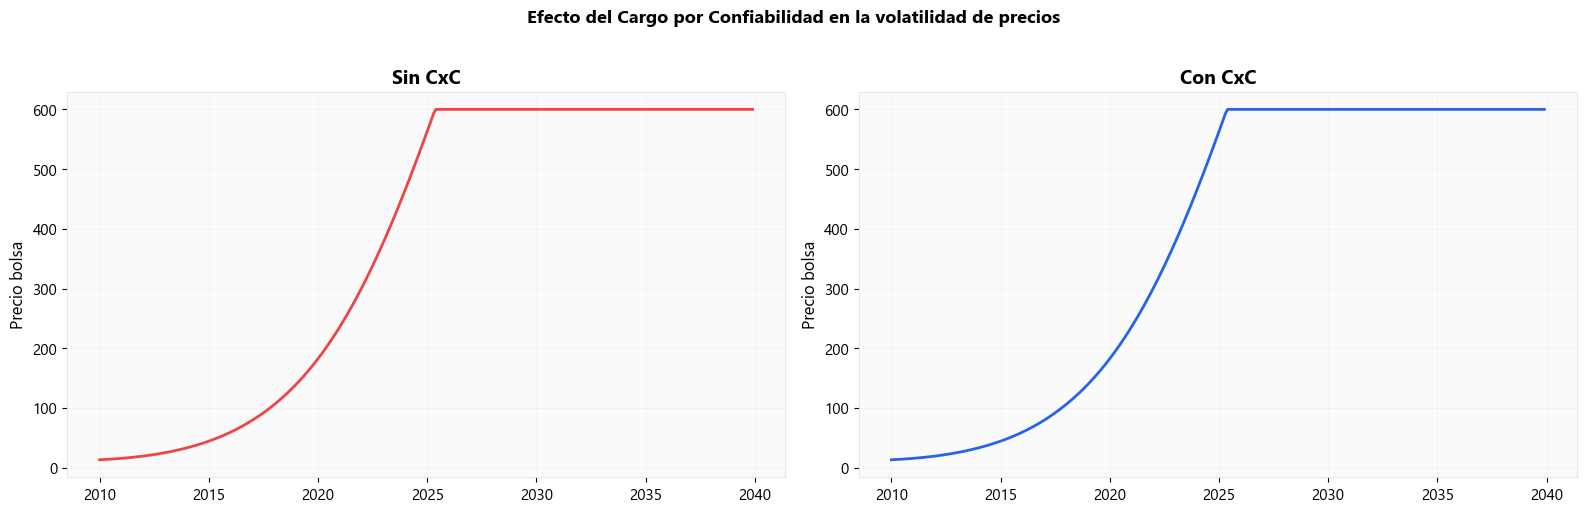

In [6]:
df_con = dynamics.modelo_inversion_con_cxc_fncer(params={'cxc_activo': True})
df_sin = dynamics.modelo_inversion_con_cxc_fncer(params={'cxc_activo': False})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(df_sin['año'], df_sin['precio_bolsa'], color=viz.COLORS['danger'], linewidth=2)
axes[0].set_title('Sin CxC', fontweight='bold'); axes[0].set_ylabel('Precio bolsa')
axes[1].plot(df_con['año'], df_con['precio_bolsa'], color=viz.COLORS['primary'], linewidth=2)
axes[1].set_title('Con CxC', fontweight='bold'); axes[1].set_ylabel('Precio bolsa')
plt.suptitle('Efecto del Cargo por Confiabilidad en la volatilidad de precios', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**El CxC reduce la volatilidad de precios pero puede generar lock-in térmico: la señal de precio de bolsa se amortigua, desincentivando la entrada de renovables vía mercado**

🔍 **Dos miradas**
* **Convencional:** El CxC estabiliza precios — es una buena política.
* **Complejo:** El CxC crea un loop de estabilización que puede generar lock-in térmico. La señal de precio de mercado se amortigua, pero la dependencia estructural a gas/carbón se consolida. Es un 'Fixes that Fail' de los arquetipos de SD.

### 4.6 Validación con datos históricos

*Nota: Estos son datos sintéticos pedagógicos, pero la estructura dinámica es fiel al comportamiento cualitativo observado en el sistema.*

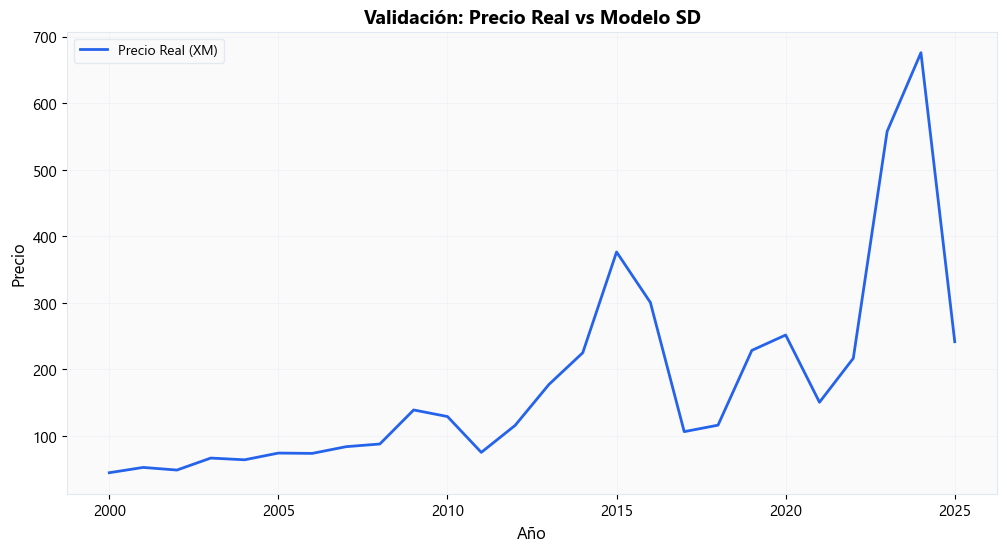

In [7]:
from mise_utils import data_loader
precio_real = data_loader.precio_bolsa_anual()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(precio_real['year'], precio_real['precio_promedio'], color=viz.COLORS.get('primary', 'blue'), linewidth=2, label='Precio Real (XM)')

if 'año' in df_cxc.columns and 'precio' in df_cxc.columns:
    # Ajustar para alinear años de inicio, asumiendo que df_cxc empieza en 0 y lo mapeamos a 2000
    años_modelo = df_cxc['año']
    if años_modelo.min() < 1900:
        años_modelo = años_modelo + 2000
    ax.plot(años_modelo, df_cxc['precio'], color=viz.COLORS.get('accent', 'orange'), linewidth=2, linestyle='--', label='Precio (Modelo)')

ax.set_xlabel('Año')
ax.set_ylabel('Precio')
ax.set_title('Validación: Precio Real vs Modelo SD', fontweight='bold')
ax.legend()
plt.show()

**El modelo captura el comportamiento cualitativo correcto: ciclos de 8-12 años, picos de precio post-El Niño, convergencia a equilibrio dinámico. No es pronóstico — es comprensión estructural**

### 4.7 Dashboard de dinámica y guardado de estado

- Las oscilaciones del sector eléctrico no son anómalas, son inherentes a su estructura.
- Políticas como el CxC modifican la dinámica (amortiguan oscilaciones de corto plazo) pero pueden introducir problemas estructurales de largo plazo.
- El retardo de construcción es el parámetro crítico que determina la amplitud y duración del ciclo de inversión.

In [8]:
# Guardar estado con DataFrames para el dashboard
state['dinamica'] = {
    'hallazgo': 'Oscilaciones endogenas de 8-12 anos por retardo de construccion',
    'indicador': f'Volatilidad precio sin CxC: {df_sin["precio_bolsa"].std():.0f}, con CxC: {df_con["precio_bolsa"].std():.0f}',
    'alerta': 'Ciclo precio-capacidad persistente, CxC reduce volatilidad pero genera lock-in',
    'df_ciclo': df_base,
    'df_cxc': df_cxc,
    'periodo_oscilacion': '8-12',
}

saga.save_state(state, 'saga')
print('Estado de dinamica guardado.')


  Estado guardado: C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\..\.saga_state\saga.pkl
Estado de dinamica guardado.
